# Cached Detections

**Note**:
- the cache's `frame_indices` are native-fps `cv2.VideoCapture` read
order, not the same as the sparse annotated `frame_number`s used in
`01_explore_ground_truth.ipynb` — so this notebook reads frames straight from
the clip's video file rather than through `Clip`/`Frame`.

In [1]:
# --- imports
from pathlib import Path
import random

import numpy as np
import supervision as sv

# --- config
CLIP_NAME = "IMG_2081"
DATA_DIR = Path("../data")
N_FRAMES_TO_SHOW = 5

## Load detections

In [2]:
# --- load the raw cache and sanity-check it
cache = np.load(DATA_DIR / CLIP_NAME / "detections_cache.npz")
print(cache.files)

['frame_indices', 'xyxy', 'confidence', 'class_id', 'mask_bits', 'mask_bit_counts', 'image_height', 'image_width']


## Decode into `sv.Detections` per frame

Masks are stored bit-packed and cropped to each detection's own box (to keep
the file small), so decoding means unpacking bits and pasting them back into
a full-frame canvas at the box's location.

In [3]:
from orc_model.data import load_cached_detections

detections_by_frame = load_cached_detections(cache)
print(f"{len(detections_by_frame)} frames with at least one cached detection")

1742 frames with at least one cached detection


## `PredictedClip` — same shape as `Clip`, backed by the cache

Lives in `orc_model.data.predictions` (promoted out of this notebook so
other notebooks can reuse it) — deliberately not `Clip`/`Frame` themselves:
`Frame.annotations` is typed as `list[InstrumentAnnotation]`, which carries
ground-truth-only fields (`description`, `manually_edited`,
`propagated_from`, a human-assigned `track_id`) that a prediction doesn't
have, and `Frame.load_image()` assumes a pre-extracted image file on disk —
cached-only frames only exist as a seek position into the video, there's no
still to `cv2.imread`.

`PredictedClip`/`PredictedFrame` mirror the *interface* (`.to_detections()`,
`.image`, indexable, auto-renders in a cell) instead, so the same plotting
code works for both ground truth and predictions without forcing predictions
through a ground-truth-shaped type. Full writeup:
[issue #8](https://github.com/Ethilink/MVP-OKcamera/issues/8).

In [4]:
from orc_model.data import PredictedClip

predicted_clip = PredictedClip.from_cache(CLIP_NAME, DATA_DIR)
print(f"{predicted_clip.name}: {len(predicted_clip)} frames with cached detections")

IMG_2081: 1742 frames with cached detections


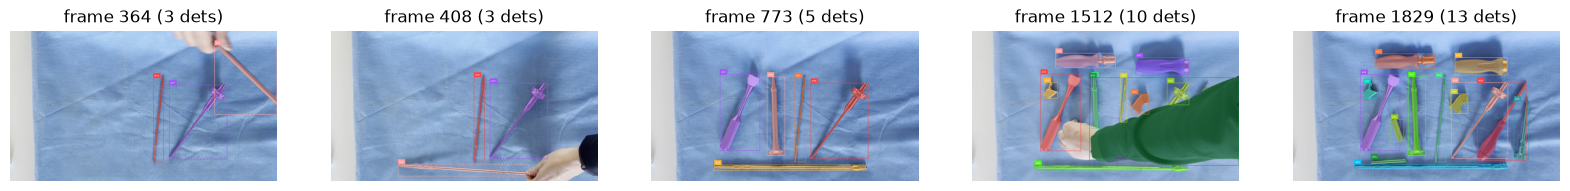

In [5]:
# --- pick a few cached frames at random and overlay their predictions
mask_annotator = sv.MaskAnnotator(opacity=0.5, color_lookup=sv.ColorLookup.INDEX)
box_annotator = sv.BoxAnnotator(color_lookup=sv.ColorLookup.INDEX)
label_annotator = sv.LabelAnnotator(color_lookup=sv.ColorLookup.INDEX)

selected = sorted(random.sample(predicted_clip.frame_indices, k=min(N_FRAMES_TO_SHOW, len(predicted_clip))))

grid_images = []
grid_titles = []
for frame_index in selected:
    frame = predicted_clip[frame_index]
    image = frame.load_image()
    detections = frame.to_detections()
    labels = [f"{conf:.2f}" for conf in detections.confidence]

    annotated = mask_annotator.annotate(image.copy(), detections)
    annotated = box_annotator.annotate(annotated, detections)
    annotated = label_annotator.annotate(annotated, detections, labels=labels)

    grid_images.append(annotated)
    grid_titles.append(f"frame {frame_index} ({len(detections)} dets)")

sv.plot_images_grid(grid_images, grid_size=(1, len(grid_images)), titles=grid_titles, size=(20, 6))